# Análisis Exploratorio de Datos

___

### Importación de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from catppuccin import PALETTE
plt.style.use(PALETTE.mocha.identifier)
import seaborn as sns

df = pd.read_csv('../data/train.csv')

___

## Primer vistazo a los datos

### Encabezados y tipos de datos

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  str    
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  str    
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  str    
dtypes: float64(5), int64(1), str(3)
memory usage: 1.3 MB


### Datos

In [3]:
df

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert
...,...,...,...,...,...,...,...,...,...
18519,18519,3.0,No,7.0,3.0,No,9.0,7.0,Extrovert
18520,18520,1.0,NaN,6.0,7.0,No,6.0,5.0,Extrovert
18521,18521,7.0,Yes,1.0,1.0,Yes,1.0,NaN,Introvert
18522,18522,NaN,Yes,1.0,0.0,Yes,5.0,2.0,Introvert


___

## Balance de variables categóricas

In [4]:
personality_counts = pd.Series(df["Personality"].value_counts())
stage_fear_counts = pd.Series(df["Stage_fear"].value_counts())
drained_counts = pd.Series(df["Drained_after_socializing"].value_counts())

fig, ax = plt.subplots(1, 3, figsize=(16, 5), dpi=480)
bars1 = ax[0].bar(personality_counts.index, personality_counts.values)
bars2 = ax[1].bar(stage_fear_counts.index, stage_fear_counts.values)
bars3 = ax[2].bar(drained_counts.index, drained_counts.values)
ax[0].bar_label(bars1)
ax[1].bar_label(bars2)
ax[2].bar_label(bars3)

ax[0].set_title("Personality")
ax[1].set_title("Stage Fear")
ax[2].set_title("Drained After Socializing")

fig.suptitle("Balance de variables categóricas", fontsize=16)
plt.show()

<Figure size 7680x2400 with 3 Axes>

___

## Distribución de variables numéricas

### Visualización de outliers

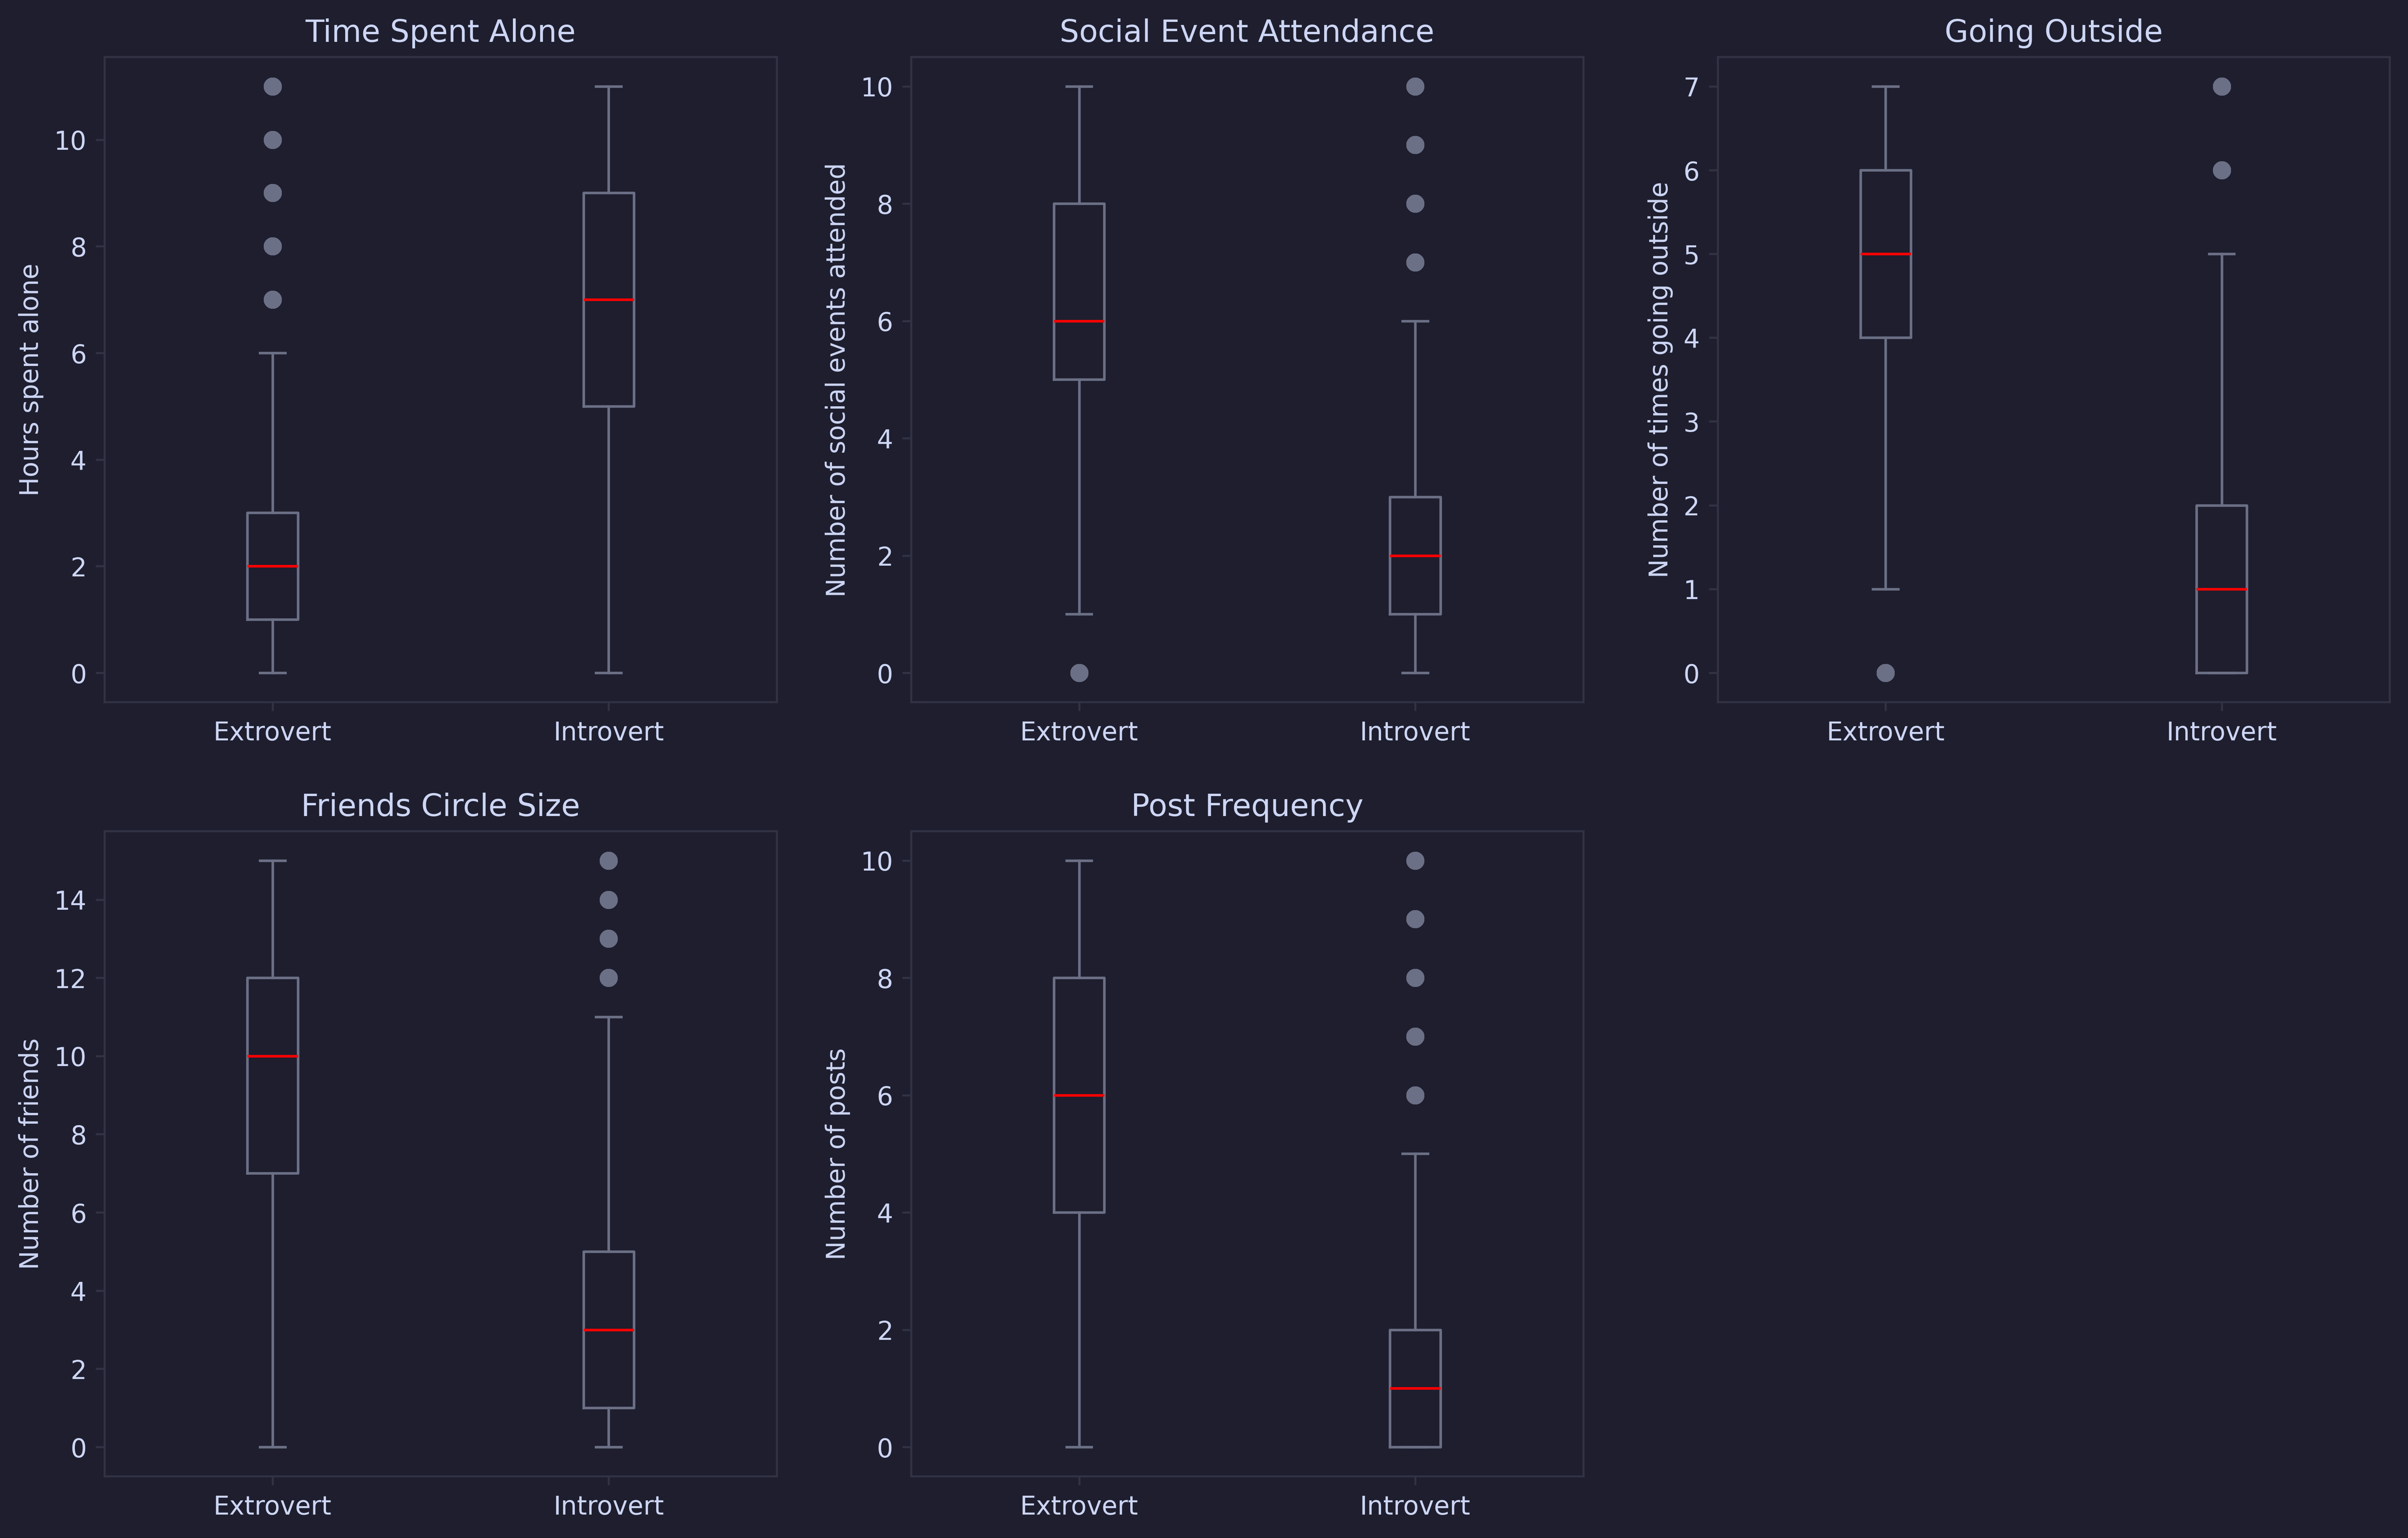

In [5]:
numeric_variables =  [
                        "Time_spent_Alone", "Social_event_attendance",
                        "Going_outside", "Friends_circle_size", "Post_frequency"
                    ]
df_clean =  df[numeric_variables + ["Personality"]].dropna()

df_ext = df_clean[df_clean["Personality"] == "Extrovert"]
df_int = df_clean[df_clean["Personality"] == "Introvert"]

fig, ax = plt.subplots(2, 3, figsize=(16, 10), dpi=480)
ax = ax.flatten()

def plot_boxplot(ax, position, variable, title, ylabel):
    ax[position].boxplot([df_ext[variable], df_int[variable]], labels=["Extrovert", "Introvert"], medianprops={"color": "red"})
    ax[position].set_title(title)
    ax[position].set_ylabel(ylabel)

plot_boxplot(ax, 0, "Time_spent_Alone", "Time Spent Alone", "Hours spent alone")
plot_boxplot(ax, 1, "Social_event_attendance", "Social Event Attendance", "Number of social events attended")
plot_boxplot(ax, 2, "Going_outside", "Going Outside", "Number of times going outside")
plot_boxplot(ax, 3, "Friends_circle_size", "Friends Circle Size", "Number of friends")
plot_boxplot(ax, 4, "Post_frequency", "Post Frequency", "Number of posts")

ax[5].axis('off')
plt.show()

### Histograma

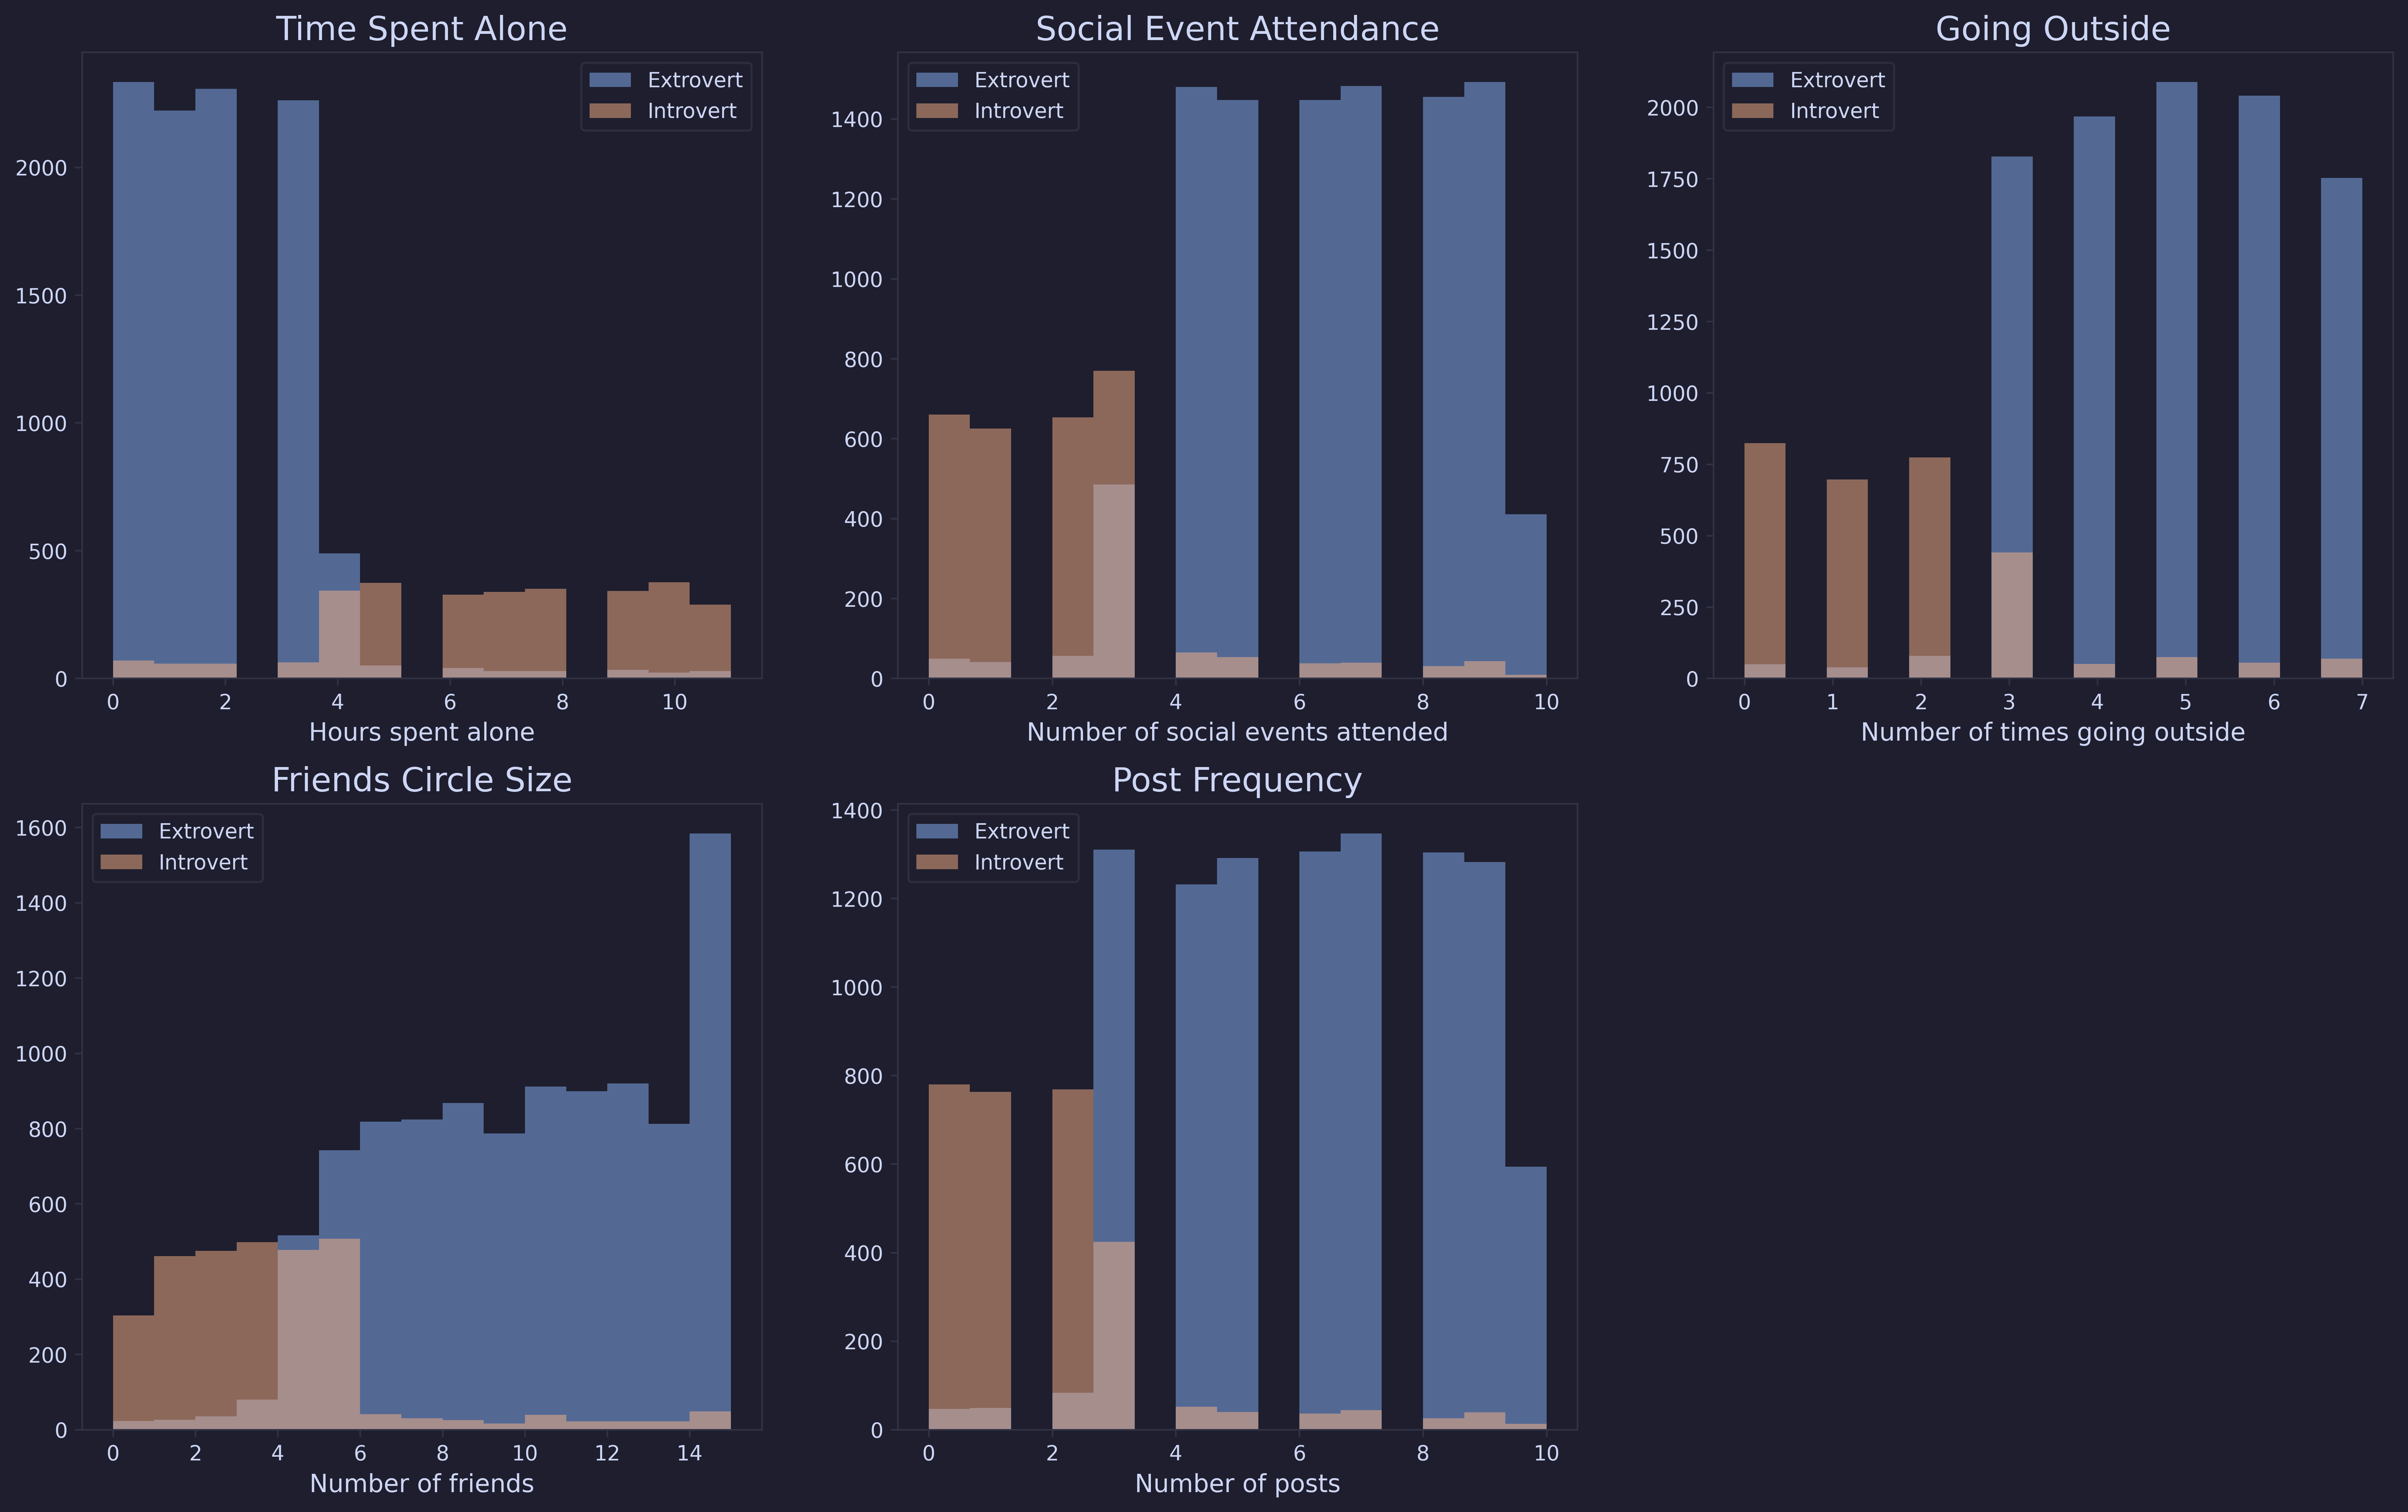

In [6]:
fig, ax = plt.subplots(2, 3, figsize=(20, 12), dpi=480)
ax = ax.flatten()

def plot_hist(ax, position, variable, title, xlabel):
    ax[position].hist(df_ext[variable], alpha=0.5, label="Extrovert", bins=15)
    ax[position].hist(df_int[variable], alpha=0.5, label="Introvert", bins=15)
    ax[position].set_title(title, fontsize=16)
    ax[position].set_xlabel(xlabel, fontsize=12)
    ax[position].legend()

plot_hist(ax, 0, "Time_spent_Alone", "Time Spent Alone", "Hours spent alone")
plot_hist(ax, 1, "Social_event_attendance", "Social Event Attendance", "Number of social events attended")
plot_hist(ax, 2, "Going_outside", "Going Outside", "Number of times going outside")
plot_hist(ax, 3, "Friends_circle_size", "Friends Circle Size", "Number of friends")
plot_hist(ax, 4, "Post_frequency", "Post Frequency", "Number of posts")
ax[5].axis('off')
plt.show()

___

## Análisis de correlación

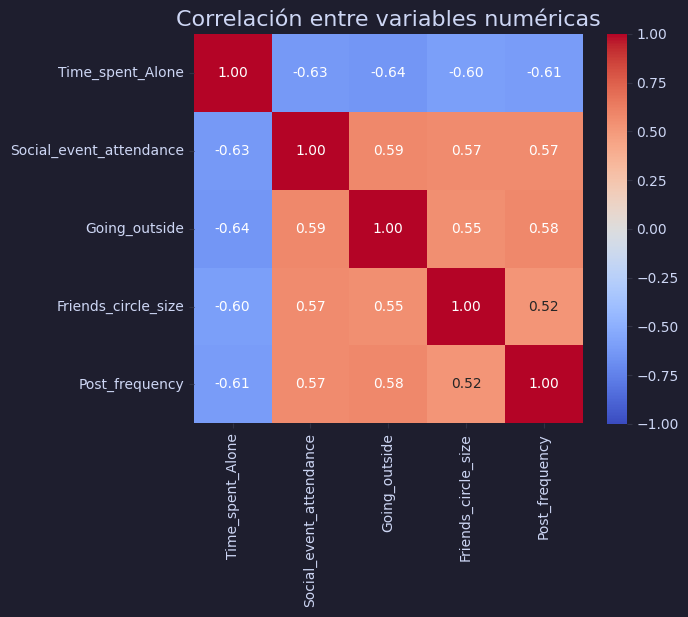

In [7]:
corr = df[numeric_variables].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, square=True)
plt.title('Correlación entre variables numéricas', fontsize=16)
plt.tight_layout()
plt.show()

___

## Análisis de missingness vs clase objetivo

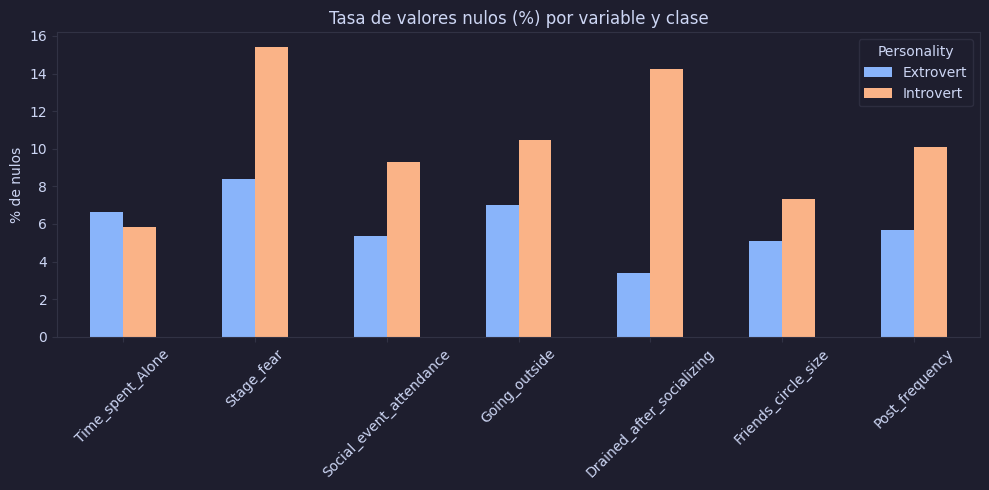

In [8]:
nulos = ['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 
                   'Going_outside', 'Drained_after_socializing', 
                   'Friends_circle_size', 'Post_frequency']

for col in nulos:
    df[f'{col}_is_null'] = df[col].isnull().astype(int)

resultados = []
for col in nulos:
    tasa = df.groupby('Personality')[f'{col}_is_null'].mean() * 100
    resultados.append(tasa.rename(col))

tabla_nulos = pd.concat(resultados, axis=1).T

tabla_nulos.plot(kind='bar', figsize=(10,5))
plt.title('Tasa de valores nulos (%) por variable y clase')
plt.ylabel('% de nulos')
plt.xticks(rotation=45)
plt.legend(title='Personality')
plt.tight_layout()
plt.show()

___

## Visualización con tSNE

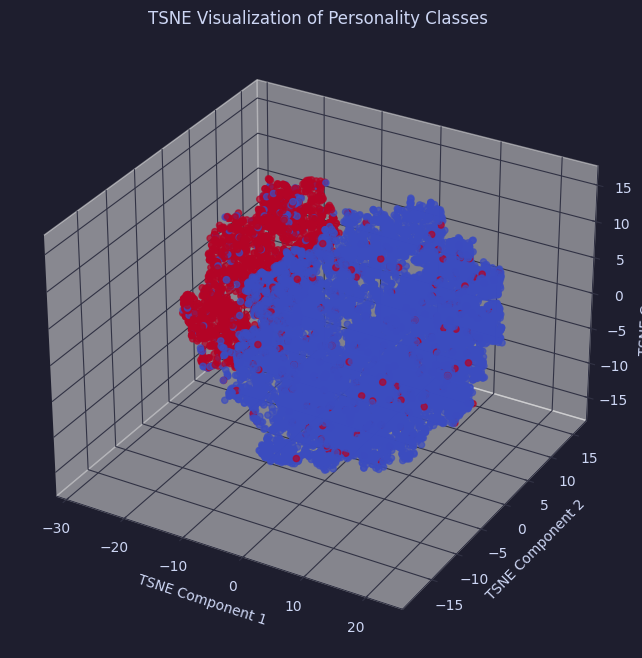

In [9]:
from sklearn.manifold import TSNE

X_3d = TSNE(n_components=3, random_state=42).fit_transform(df_clean[numeric_variables])
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=df_clean['Personality'].map({'Extrovert': 0, 'Introvert': 1}), cmap='coolwarm', alpha=0.7)
ax.set_xlabel('TSNE Component 1')
ax.set_ylabel('TSNE Component 2')
ax.set_zlabel('TSNE Component 3')
ax.set_title('TSNE Visualization of Personality Classes')
plt.show()

### Visualización interactiva

In [10]:
from sklearn.manifold import TSNE
import plotly.express as px
y = df_clean.iloc[:, -1].values
fig = px.scatter_3d(x=X_3d[:,0], y=X_3d[:,1], z=X_3d[:,2],
                    color=y.astype(str), title="t-SNE 3D")
fig.show()

___

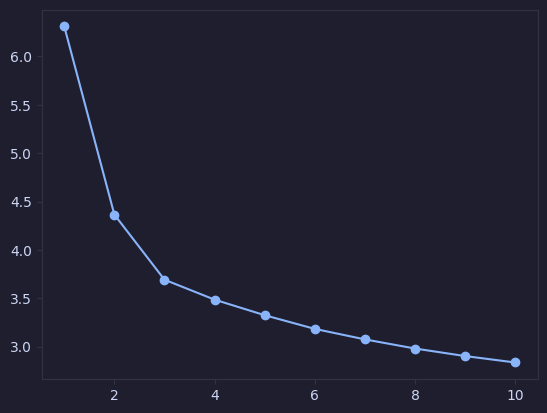

In [12]:
from scipy.cluster.vq import kmeans, vq
import numpy as np

distortions = []
K = range(1, 11)
for k in K:
    kmeanModel, dist = kmeans(df_clean[numeric_variables].values, k)
    distortions.append(dist)

plt.plot(K, distortions, marker='o')
plt.show()